In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import warnings
pd.options.display.max_columns=None

In [2]:
test = pd.read_csv('/kaggle/input/world-championship-2023-risk-evaluation/test_data_post.csv')
test.head() 

,ID,Tweets
0,1,knowing what s right for you and your body isn...
1,2,looks like we need to boycott walmart exxonmob...
2,3,#cvshealth says of its employees are racially ...
3,4,be a part of cvshealth on our journey to trans...
4,5,juddlegum ford walmart delta deloitte nrcc lib...


In [3]:
train = pd.read_csv('/kaggle/input/world-championship-2023-risk-evaluation/train_data.csv')
train.head()

,Tweets,Risk Analysis
0,interested in a job in epping nh this could be...,0.0
1,community violence cv is a public health epide...,1.0
2,cvs took a step that shows it s gearing up to ...,0.0
3,this job is now open at cvs health in henderso...,0.0
4,at cvs health we are committed to empowering m...,0.0


In [4]:
combined = pd.concat([train,test])
combined.head()

,Tweets,Risk Analysis,ID
0,interested in a job in epping nh this could be...,0.0,NaN
1,community violence cv is a public health epide...,1.0,NaN
2,cvs took a step that shows it s gearing up to ...,0.0,NaN
3,this job is now open at cvs health in henderso...,0.0,NaN
4,at cvs health we are committed to empowering m...,0.0,NaN


In [5]:
combined.info()

<class 'pandas.core.frame.DataFrame'>
Index: 25256 entries, 0 to 5051
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Tweets         25256 non-null  object 
 1   Risk Analysis  20204 non-null  float64
 2   ID             5052 non-null   float64
dtypes: float64(2), object(1)
memory usage: 789.2+ KB


In [6]:
combined.dtypes

Tweets            object
Risk Analysis    float64
ID               float64
dtype: object

In [7]:
combined.isnull().sum()/len(combined*100)

Tweets           0.000000
Risk Analysis    0.200032
ID               0.799968
dtype: float64

In [8]:
combined.describe().T

,count,mean,std,min,25%,50%,75%,max
Risk Analysis,20204.0,0.318105,0.465752,0.0,0.00,0.0,1.00,1.0
ID,5052.0,2526.500000,1458.531110,1.0,1263.75,2526.5,3789.25,5052.0


In [9]:
combined.shape

(25256, 3)

<Axes: >

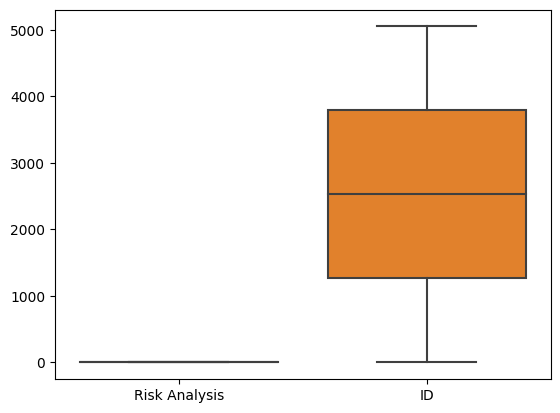

In [10]:
sns.boxplot(combined)

<Axes: >

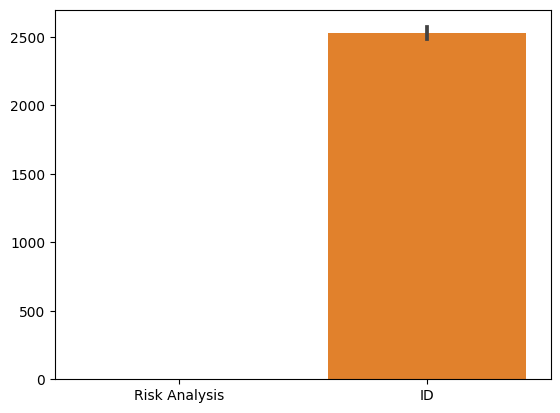

In [11]:
sns.barplot(combined)

<Axes: ylabel='Density'>

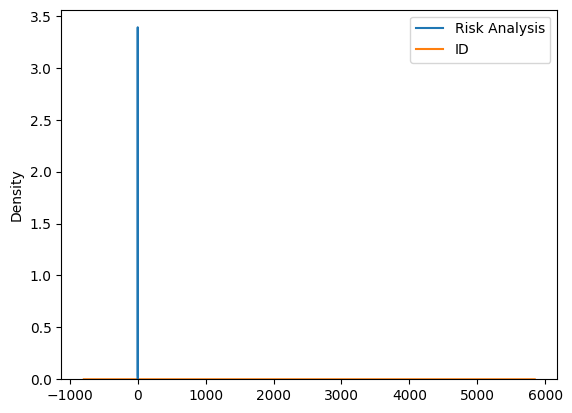

In [12]:
sns.kdeplot(combined)

/opt/conda/lib/python3.10/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


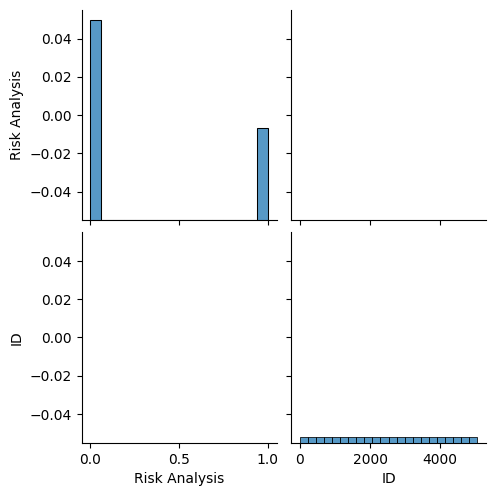

In [13]:
sns.pairplot(combined)

<Axes: >

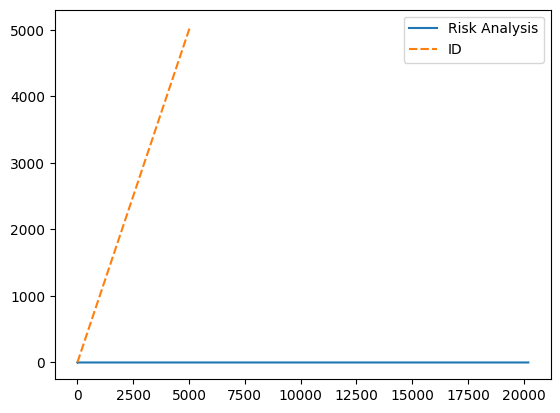

In [14]:
sns.lineplot(combined)b

<Axes: >

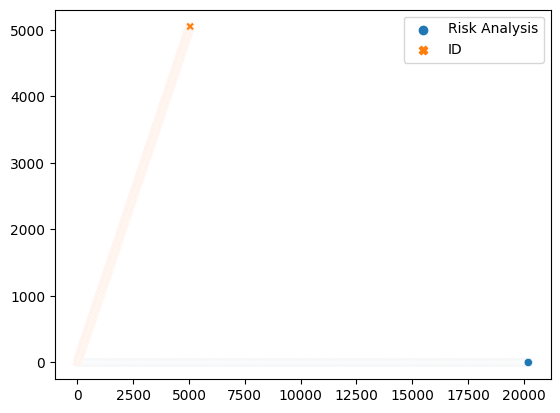

In [15]:
sns.scatterplot(combined)

<Axes: >

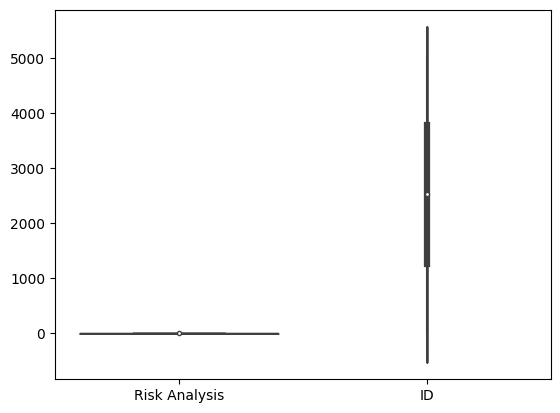

In [16]:
sns.violinplot(combined)

In [17]:
combined.skew

<bound method NDFrame._add_numeric_operations.<locals>.skew of                                                  Tweets  Risk Analysis      ID
0     interested in a job in epping nh this could be...            0.0     NaN
1     community violence cv is a public health epide...            1.0     NaN
2     cvs took a step that shows it s gearing up to ...            0.0     NaN
3     this job is now open at cvs health in henderso...            0.0     NaN
4     at cvs health we are committed to empowering m...            0.0     NaN
...                                                 ...            ...     ...
5047  cvs health is hiring in ma click the link in o...            NaN  5048.0
5048  merck cvs health aim to provide p amp l experi...            NaN  5049.0
5049  #scottsdale #jobs #hiring #opportunity cvs hea...            NaN  5050.0
5050  here s what i took to rejuvenate my health by ...            NaN  5051.0
5051  last week i learned that the cdc was allowing ...            N

In [18]:
combined.kurt

<bound method NDFrame._add_numeric_operations.<locals>.kurt of                                                  Tweets  Risk Analysis      ID
0     interested in a job in epping nh this could be...            0.0     NaN
1     community violence cv is a public health epide...            1.0     NaN
2     cvs took a step that shows it s gearing up to ...            0.0     NaN
3     this job is now open at cvs health in henderso...            0.0     NaN
4     at cvs health we are committed to empowering m...            0.0     NaN
...                                                 ...            ...     ...
5047  cvs health is hiring in ma click the link in o...            NaN  5048.0
5048  merck cvs health aim to provide p amp l experi...            NaN  5049.0
5049  #scottsdale #jobs #hiring #opportunity cvs hea...            NaN  5050.0
5050  here s what i took to rejuvenate my health by ...            NaN  5051.0
5051  last week i learned that the cdc was allowing ...            N

In [13]:
cat_cols = combined.select_dtypes(include='object')

In [14]:
for i in cat_cols:
    combined[i].value_counts()
    print(i)
    print(''*50)

Tweets



In [11]:
num_cols = combined.select_dtypes(include='number')

In [12]:
for i in num_cols:
    print(combined[i].value_counts())
    print(i)
    print(''*50)

Risk Analysis
0.0    13777
1.0     6427
Name: count, dtype: int64
Risk Analysis

ID
1.0       1
3366.0    1
3373.0    1
3372.0    1
3371.0    1
         ..
1684.0    1
1683.0    1
1682.0    1
1681.0    1
5052.0    1
Name: count, Length: 5052, dtype: int64
ID



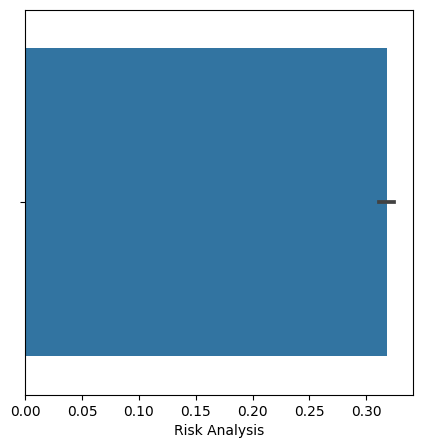

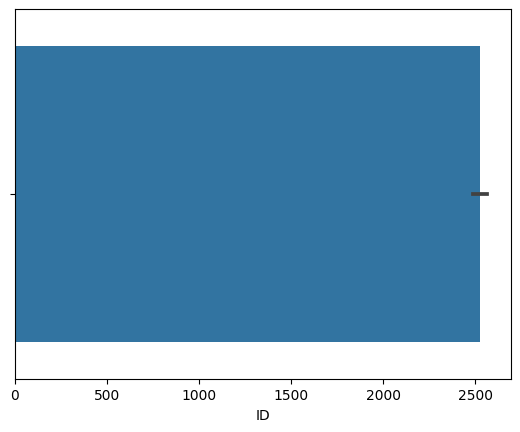

In [23]:
plt.figure(figsize=(5,5))
x=i
for i in num_cols:
    sns.barplot(data=combined,x=i)
    print('\n')
    plt.show()

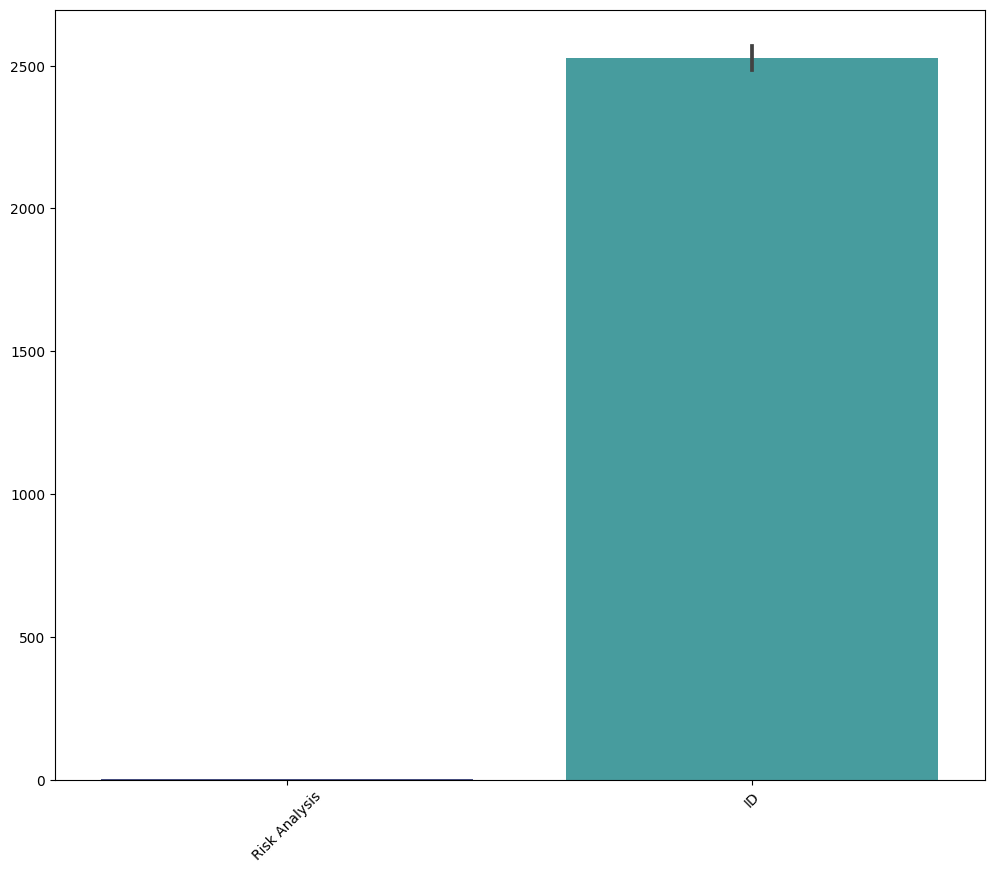

In [24]:
plt.figure(figsize=(12,10))
sns.barplot(data=combined,palette='mako');
plt.xticks(rotation=45);

(array([0, 1]), [Text(0, 0, 'Risk Analysis'), Text(1, 0, 'ID')])

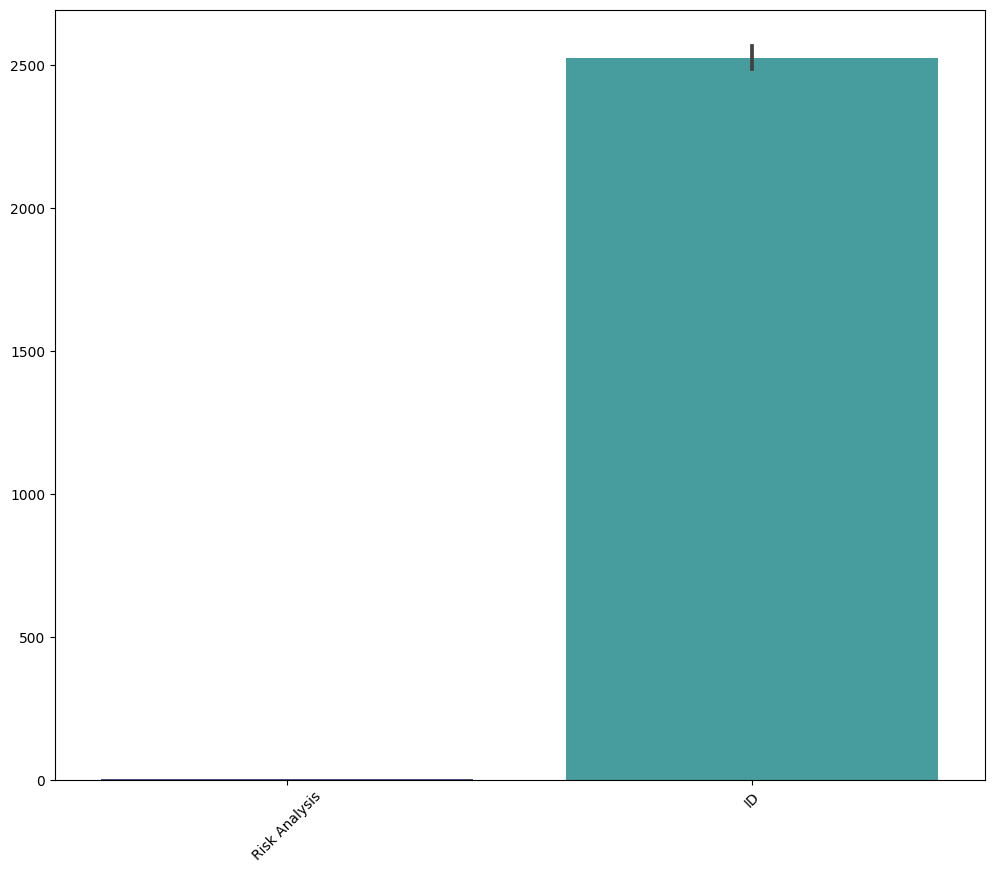

In [25]:
plt.figure(figsize=(12,10))
sns.barplot(data=combined,palette='mako')
plt.xticks(rotation=45)

In [26]:
combined.shape

(25256, 3)

In [27]:
combined.head()

,Tweets,Risk Analysis,ID
0,interested in a job in epping nh this could be...,0.0,NaN
1,community violence cv is a public health epide...,1.0,NaN
2,cvs took a step that shows it s gearing up to ...,0.0,NaN
3,this job is now open at cvs health in henderso...,0.0,NaN
4,at cvs health we are committed to empowering m...,0.0,NaN


In [28]:
combined.shape

(25256, 3)

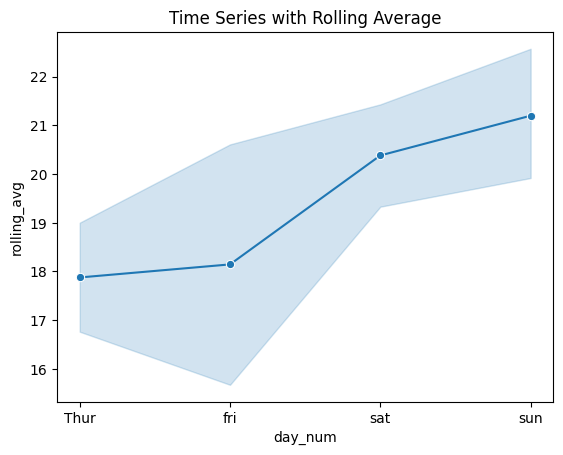

In [18]:
df_tips = sns.load_dataset('tips')
df_tips['day_num'] = df_tips['day'].astype('category').cat.codes

df_tips['rolling_avg'] = df_tips['total_bill'].rolling(window=3).mean()

sns.lineplot(x='day_num', y='rolling_avg',data=df_tips, marker='o')
plt.xticks(ticks=[0,1,2,3],labels=['Thur','fri','sat','sun'])
plt.title("Time Series with Rolling Average")
plt.show()

In [22]:
combined.columns

Index(['Tweets', 'Risk Analysis', 'ID'], dtype='object')

In [23]:
combined.shape

(25256, 3)